# Name:N.Vishnu Vardhan Reddy
# CSE

Dataset Description:

The dataset contains 499 records across 7 columns, tracking land extent (in hectares) for Kumta, Kundapur, Puttur, and Moodabidri divisions from 1992 to 2490. It includes a serial number, year, and total land extent, with some missing values. On average, each division records 125 hectares, ranging from 5 to 653 hectares, while total land extent varies between 14 and 1615.5 hectares. This dataset can help analyze historical land distribution trends. Let me know if you need further processing or visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Expanded_Dataset.csv")
df

,Sl NO,Year,Kumta Division-Extent in Hectare,Kundapur Division-Extent in Hectare,Puttur Division-Extent in Hectare,Moodabidri Division-Extent in Hectare,Total
0,1,1992,NaN,70.0,85.0,25.0,180.0
1,2,1993,NaN,NaN,14.0,NaN,14.0
2,3,1994,NaN,NaN,NaN,NaN,NaN
3,4,1995,50.0,50.0,51.0,50.0,201.0
4,5,1996,125.0,150.0,100.0,100.0,475.0
...,...,...,...,...,...,...,...
494,496,2486,148.0,160.0,140.0,110.0,558.0
495,497,2487,149.0,83.0,163.0,51.0,446.0
496,498,2488,122.0,193.0,92.0,85.0,492.0
497,499,2489,115.0,104.0,70.0,163.0,452.0


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 7 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Sl NO                                  499 non-null    int64  
 1   Year                                   499 non-null    int64  
 2   Kumta Division-Extent in Hectare       493 non-null    float64
 3   Kundapur Division-Extent in Hectare    492 non-null    float64
 4   Puttur Division-Extent in Hectare      495 non-null    float64
 5   Moodabidri Division-Extent in Hectare  491 non-null    float64
 6   Total                                  496 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 27.4 KB
None


# top 5 values 

In [3]:
print(df.head())

   Sl NO  Year  Kumta Division-Extent in Hectare  \
0      1  1992                               NaN   
1      2  1993                               NaN   
2      3  1994                               NaN   
3      4  1995                              50.0   
4      5  1996                             125.0   

   Kundapur Division-Extent in Hectare  Puttur Division-Extent in Hectare  \
0                                 70.0                               85.0   
1                                  NaN                               14.0   
2                                  NaN                                NaN   
3                                 50.0                               51.0   
4                                150.0                              100.0   

   Moodabidri Division-Extent in Hectare  Total  
0                                   25.0  180.0  
1                                    NaN   14.0  
2                                    NaN    NaN  
3                       

In [4]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Sl NO                                    0
Year                                     0
Kumta Division-Extent in Hectare         6
Kundapur Division-Extent in Hectare      7
Puttur Division-Extent in Hectare        4
Moodabidri Division-Extent in Hectare    8
Total                                    3
dtype: int64


# Missing Values After Filling

In [5]:
df_filled = df.copy()
for col in df.columns[2:]:  
    df_filled[col].fillna(df_filled[col].median(), inplace=True)

In [6]:
print("Missing Values After Filling:\n", df_filled.isnull().sum())

Missing Values After Filling:
 Sl NO                                    0
Year                                     0
Kumta Division-Extent in Hectare         0
Kundapur Division-Extent in Hectare      0
Puttur Division-Extent in Hectare        0
Moodabidri Division-Extent in Hectare    0
Total                                    0
dtype: int64


# dropping nan values

In [7]:
df.dropna()

,Sl NO,Year,Kumta Division-Extent in Hectare,Kundapur Division-Extent in Hectare,Puttur Division-Extent in Hectare,Moodabidri Division-Extent in Hectare,Total
3,4,1995,50.0,50.0,51.0,50.0,201.0
4,5,1996,125.0,150.0,100.0,100.0,475.0
5,6,1997,100.0,125.0,100.0,100.0,425.0
6,7,1998,32.0,30.0,60.0,45.0,167.0
7,8,1999,73.0,66.0,139.0,33.0,311.0
...,...,...,...,...,...,...,...
494,496,2486,148.0,160.0,140.0,110.0,558.0
495,497,2487,149.0,83.0,163.0,51.0,446.0
496,498,2488,122.0,193.0,92.0,85.0,492.0
497,499,2489,115.0,104.0,70.0,163.0,452.0


# different types of hist plots

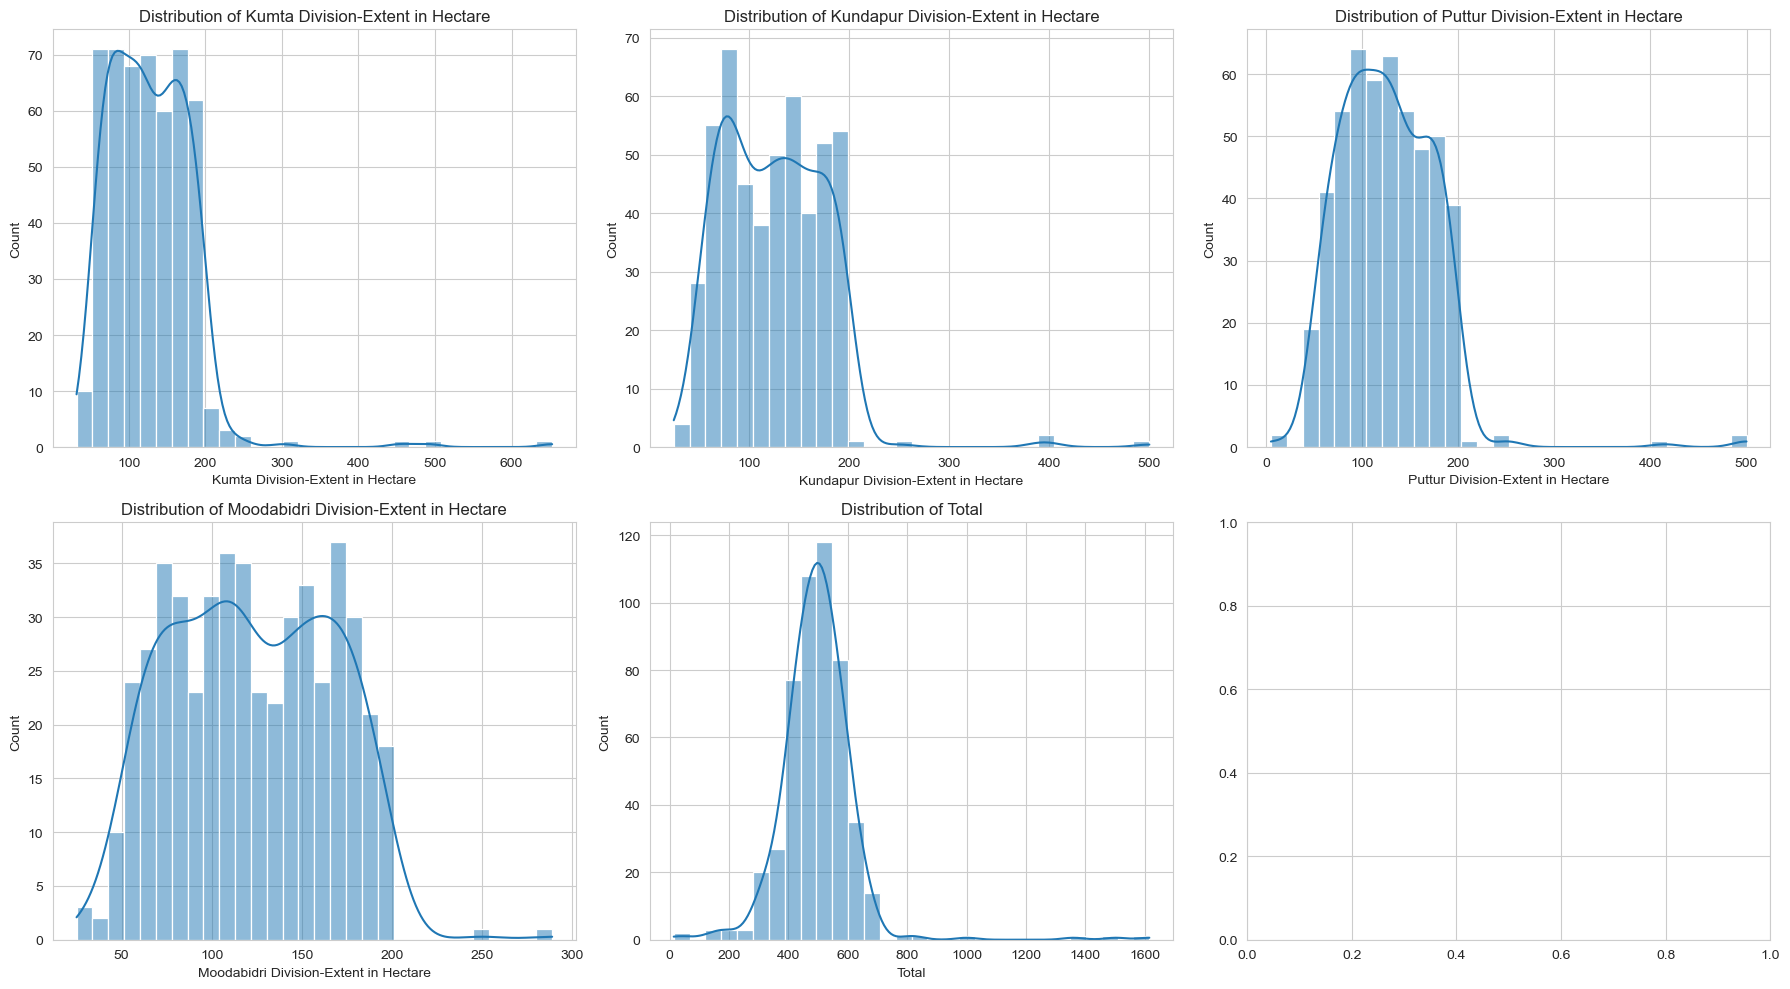

In [8]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
columns_to_plot = df.columns[2:]
for col, ax in zip(columns_to_plot, axes.flatten()):
    sns.histplot(df_filled[col], kde=True, bins=30, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


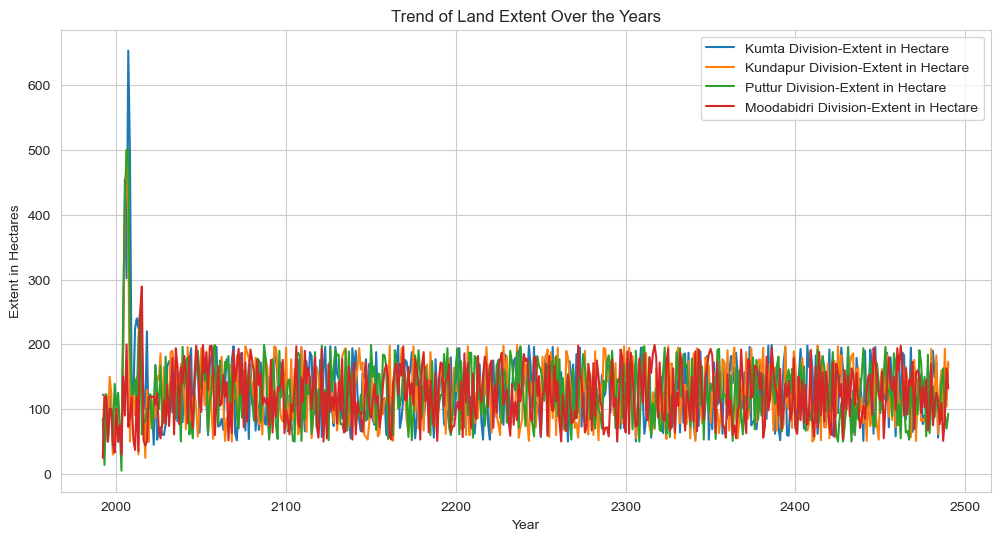

In [9]:
plt.figure(figsize=(12, 6))
for col in df.columns[2:-1]: 
    plt.plot(df_filled["Year"], df_filled[col], label=col)
plt.xlabel("Year")
plt.ylabel("Extent in Hectares")
plt.title("Trend of Land Extent Over the Years")
plt.legend()
plt.show()

# hist plot of Kumta Division-Extent in Hectare with brown color

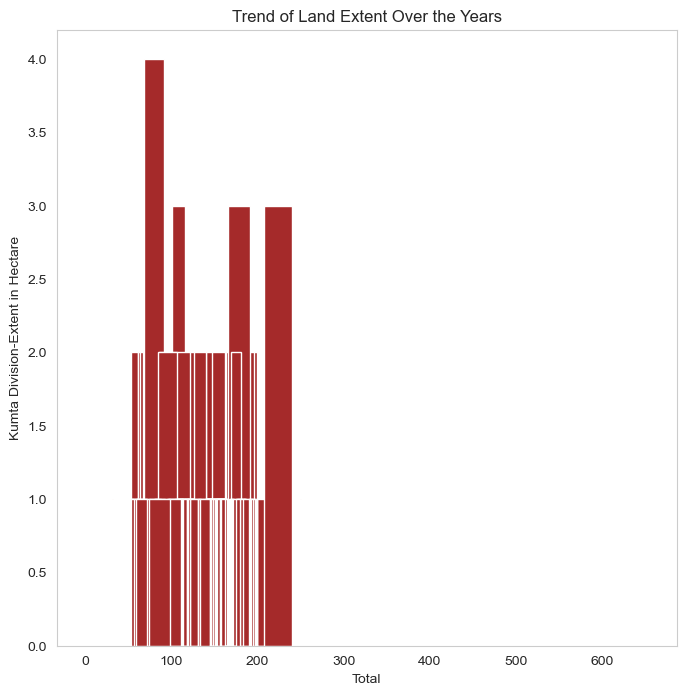

In [10]:
df1=df.groupby('Total')['Kumta Division-Extent in Hectare']
df1.hist(color = 'brown',figsize=[8,8],grid=False,bins=5)
plt.title("Trend of Land Extent Over the Years")
plt.xlabel("Total")
plt.ylabel("Kumta Division-Extent in Hectare")
plt.show()

# sactter plot of Kumta Division-Extent in Hectare with orange color

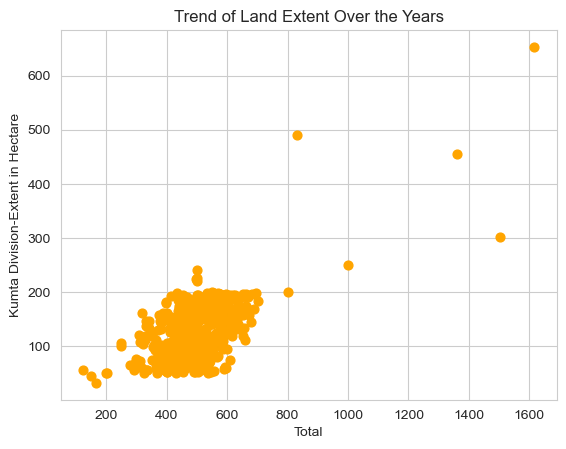

In [12]:
df.plot.scatter(x='Total',y='Kumta Division-Extent in Hectare',color='orange',s=40)
plt.title("Trend of Land Extent Over the Years")
plt.show()

# box plot of Kumta Division-Extent in Hectare with blue color

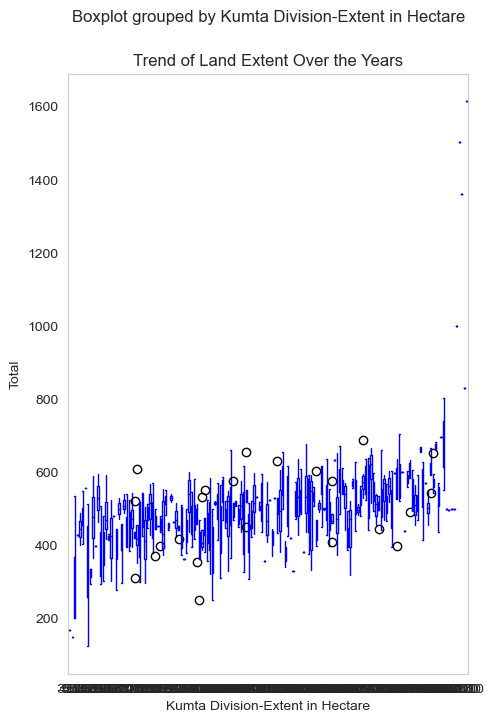

In [14]:
df.boxplot(by='Kumta Division-Extent in Hectare', column =['Total'], grid = False,color='blue',figsize=[5,8])
plt.title("Trend of Land Extent Over the Years")
plt.ylabel("Total")
plt.show()

# plot line  of Kumta Division-Extent in Hectare with orange color

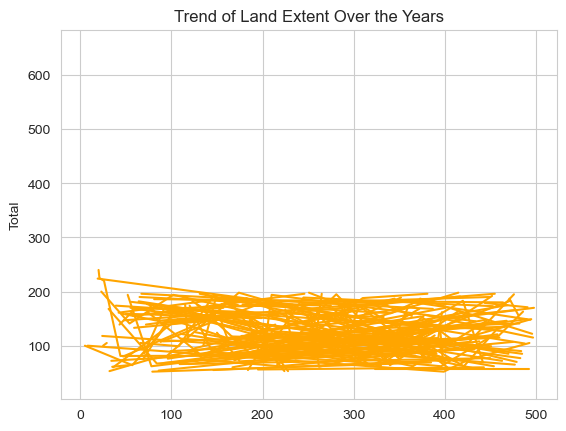

In [15]:
df1.plot.line(x='Kumta Division-Extent in Hectare',y='Total',color='orange')
plt.title("Trend of Land Extent Over the Years")
plt.ylabel("Total")
plt.show()

# pie plot  of Kumta Division-Extent in Hectare

Text(0.5, 1.0, 'Trend of Land Extent Over the Years')

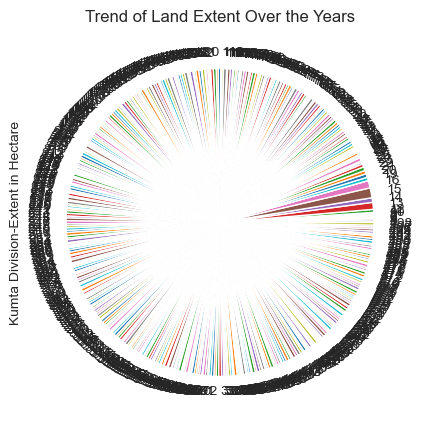

In [16]:
df['Kumta Division-Extent in Hectare'].plot(kind='pie',subplots=True,figsize=(5,5))
plt.title("Trend of Land Extent Over the Years")

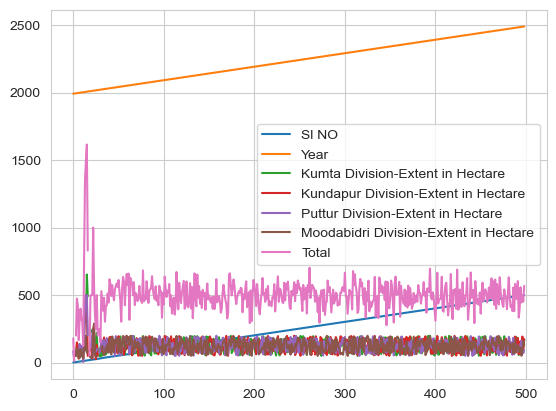

In [17]:
df.plot()
plt.show()

# box plot of Kumta Division-Extent in Hectare with red color

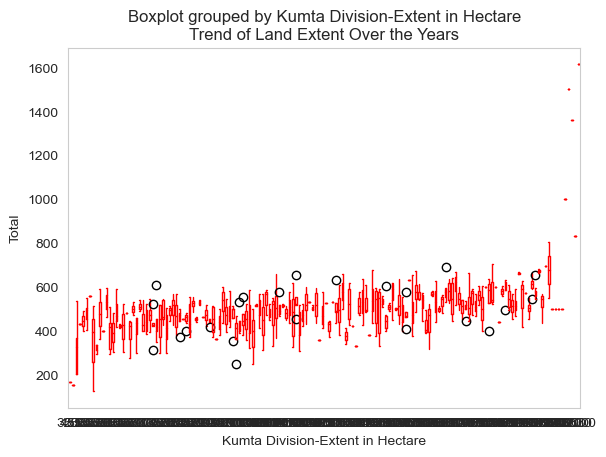

In [18]:
df.boxplot(by='Kumta Division-Extent in Hectare', column =['Total'], grid = False,color='red')
plt.title("Trend of Land Extent Over the Years")
plt.ylabel("Total")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

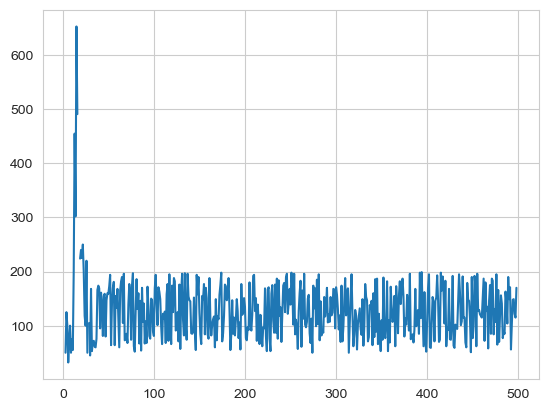

In [19]:
import matplotlib.pyplot as plt
df['Kumta Division-Extent in Hectare'].plot()
plt.show

# histplot with all columns in seaborn with

<AxesSubplot:ylabel='Count'>

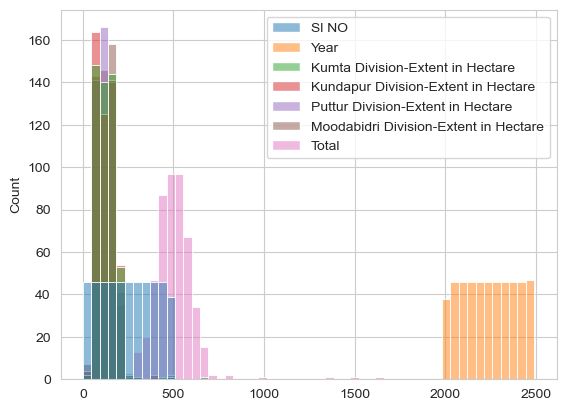

In [20]:
sns.histplot(df)

# line plot Kumta Division-Extent in Hectare in seaborn with whitegrid

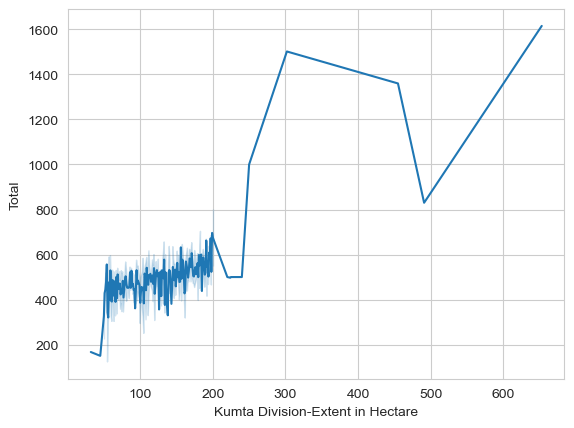

In [24]:

sns.lineplot(x="Kumta Division-Extent in Hectare", y="Total", data=df)
sns.set_style('white')
plt.show()

# line plot  Kumta Division-Extent in Hectare in seaborn with despine

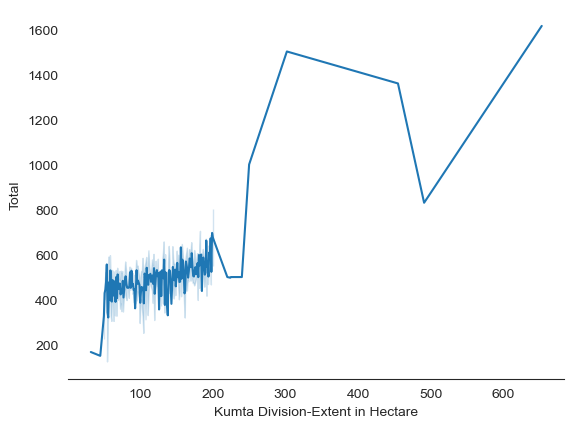

In [25]:
sns.lineplot(x="Kumta Division-Extent in Hectare", y="Total", data=df)
sns.despine(left=True)
plt.show()

# Visualization: Total Trend of Land Extent Over the Years in Kumta Division-Extent in Hectare

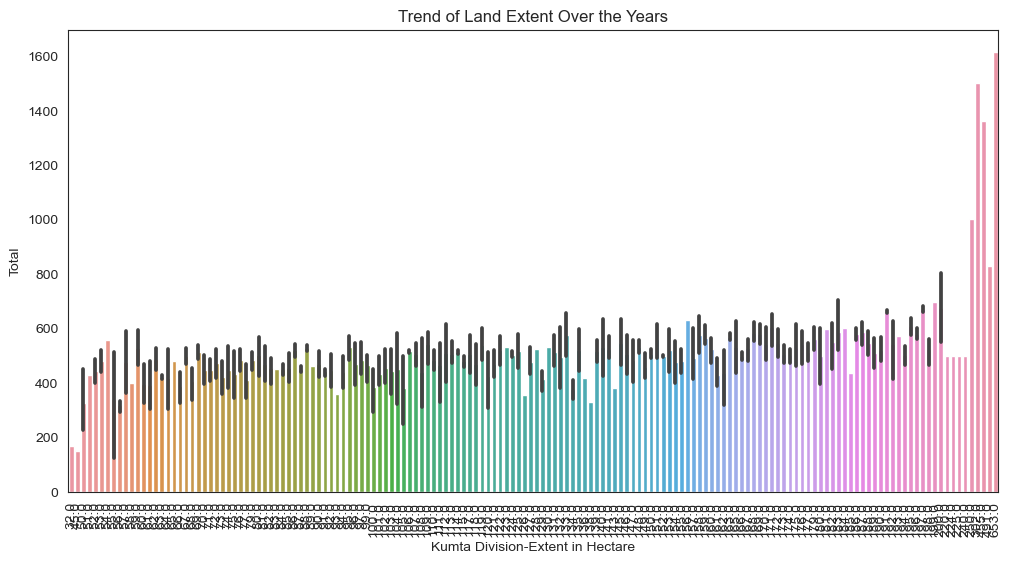

In [27]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df.reset_index(), x='Kumta Division-Extent in Hectare', y='Total')
plt.title('Trend of Land Extent Over the Years')
plt.xlabel('Kumta Division-Extent in Hectare')
plt.ylabel('Total')
plt.xticks(rotation=90)
plt.show()


# pair plot for Total Trend of Land Extent Over the Years in Kumta Division-Extent in Hectare

<Figure size 1200x600 with 0 Axes>

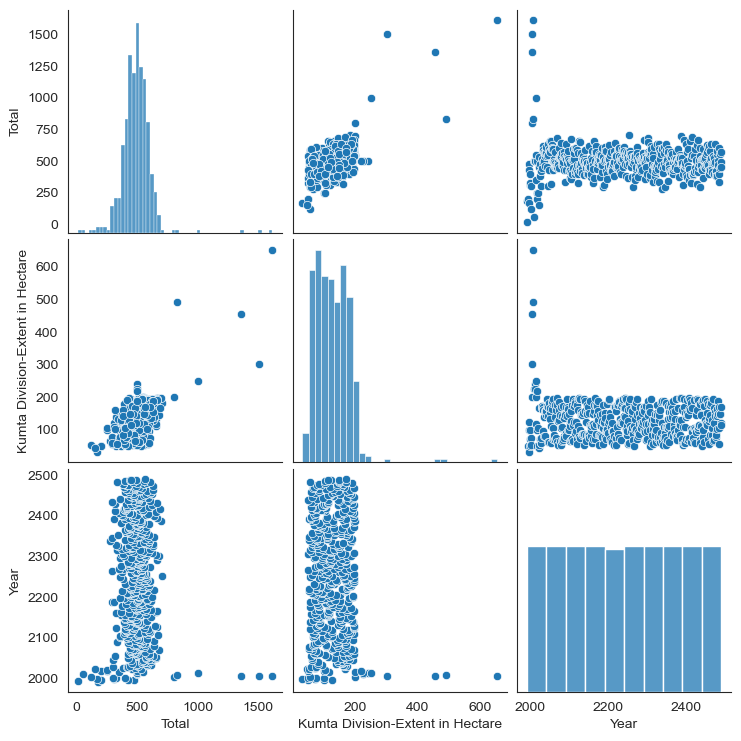

In [28]:
plt.figure(figsize=(12, 6))
sns.pairplot(df, vars=['Total', 'Kumta Division-Extent in Hectare', 'Year'])
plt.show()

# hist plot of Kundapur Division-Extent in Hectare  in Hectare with brown color

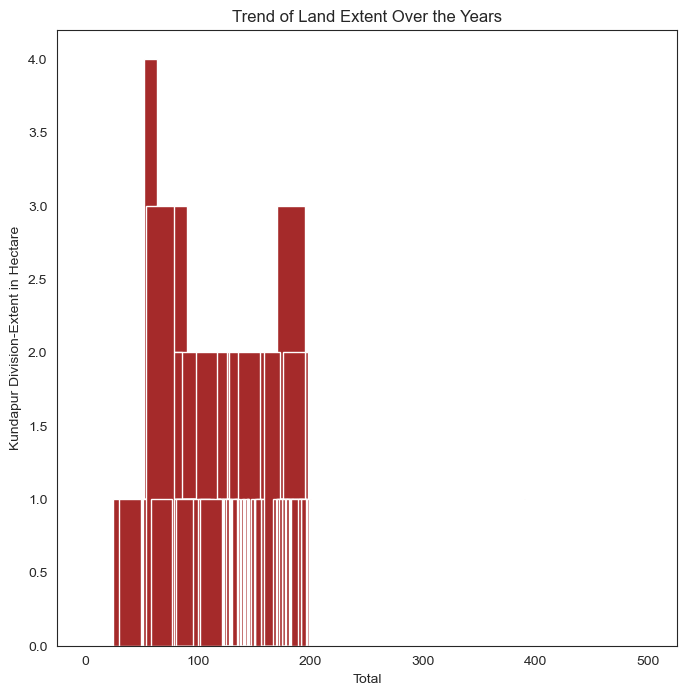

In [29]:
import matplotlib.pyplot as plt
df1=df.groupby('Total')['Kundapur Division-Extent in Hectare']
df1.hist(color = 'brown',figsize=[8,8],grid=False,bins=5)
plt.title("Trend of Land Extent Over the Years")
plt.xlabel("Total")
plt.ylabel("Kundapur Division-Extent in Hectare")
plt.show()

# sactter plot of Kundapur Division-Extent in Hectare with orange color

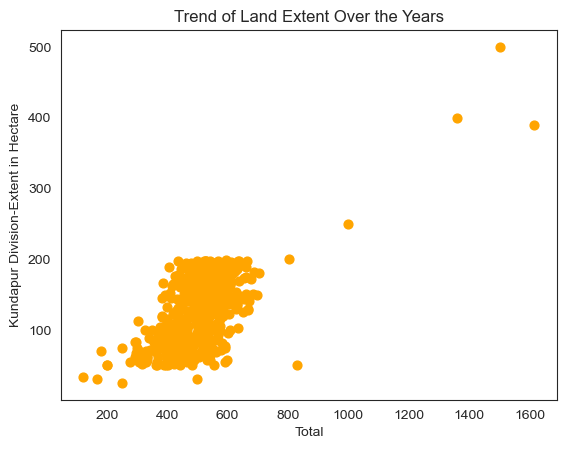

In [30]:
df.plot.scatter(x='Total',y='Kundapur Division-Extent in Hectare',color='orange',s=40)
plt.title("Trend of Land Extent Over the Years")
plt.show()

# box plot of Kundapur Division-Extent in Hectare with blue color

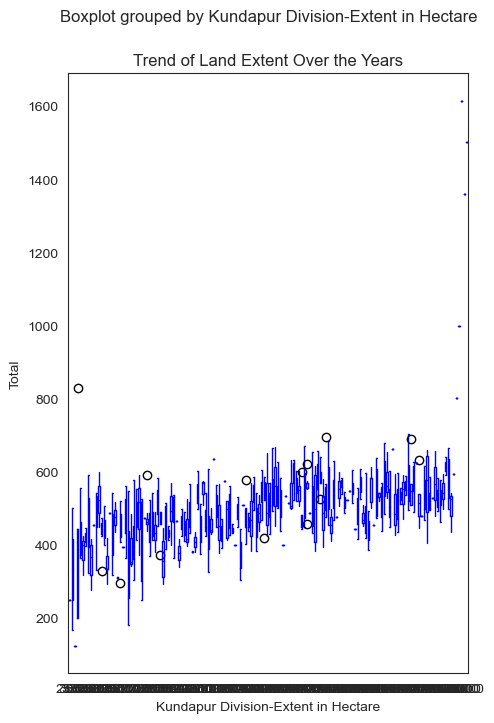

In [31]:
df.boxplot(by='Kundapur Division-Extent in Hectare', column =['Total'], grid = False,color='blue',figsize=[5,8])
plt.title("Trend of Land Extent Over the Years")
plt.ylabel("Total")
plt.show()


# plot line  of Kundapur Division-Extent in Hectare with orange color

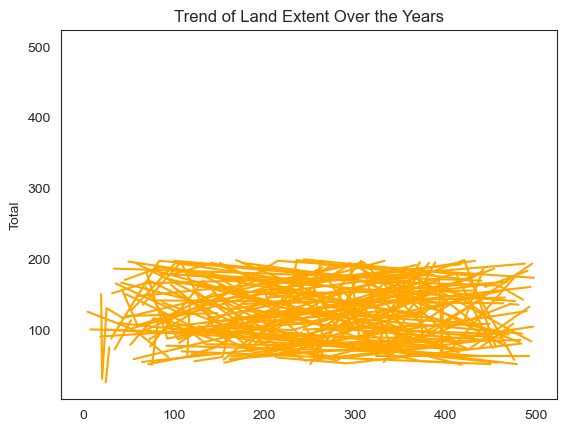

In [32]:
df1.plot.line(x='Kundapur Division-Extent in Hectare',y='Total',color='orange')
plt.title("Trend of Land Extent Over the Years")
plt.ylabel("Total")
plt.show()


# pie plot  of Kundapur Division-Extent in Hectare

Text(0.5, 1.0, 'Trend of Land Extent Over the Years')

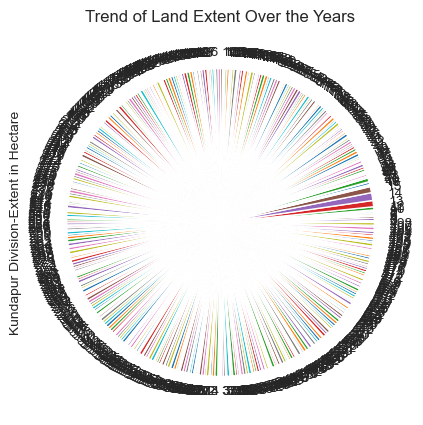

In [33]:
df['Kundapur Division-Extent in Hectare'].plot(kind='pie',subplots=True,figsize=(5,5))
plt.title("Trend of Land Extent Over the Years")

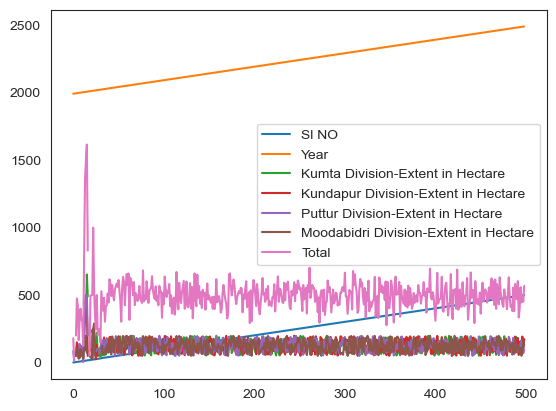

In [34]:
df.plot()
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

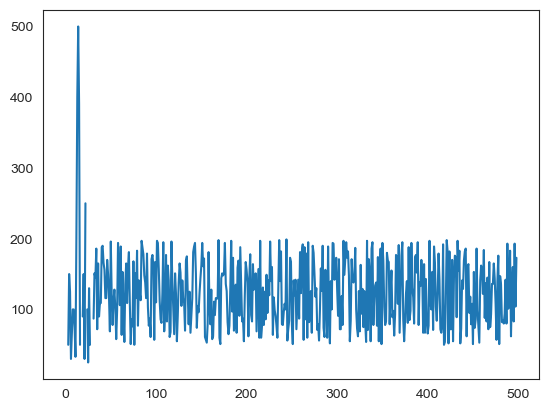

In [35]:
import matplotlib.pyplot as plt
df['Kundapur Division-Extent in Hectare'].plot()
plt.show

# histplot with all columns in seaborn with

<AxesSubplot:ylabel='Count'>

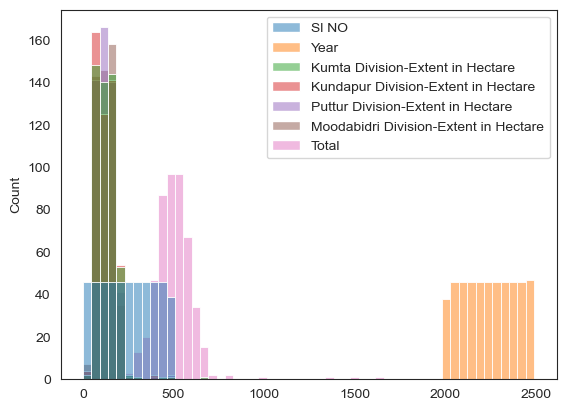

In [36]:
sns.histplot(df)

# Kundapur Division-Extent in Hectare in seaborn with lineplot

<AxesSubplot:title={'center':'Trend of Land Extent Over the Years'}, xlabel='Kundapur Division-Extent in Hectare', ylabel='Total'>

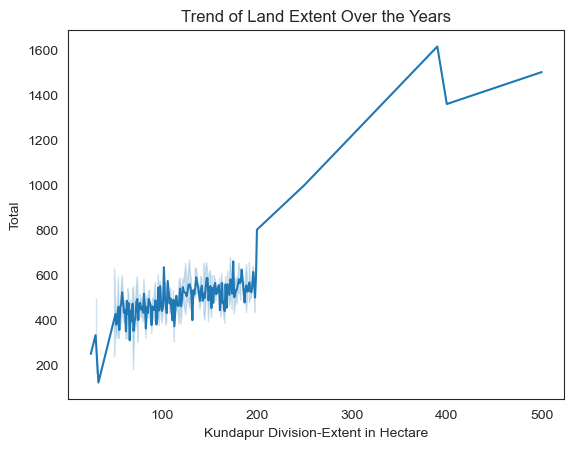

In [37]:
plt.title('Trend of Land Extent Over the Years')
sns.lineplot(x="Kundapur Division-Extent in Hectare", y="Total", data=df) 

# line plot of Kundapur Division-Extent in Hectare in seaborn with darkgrid

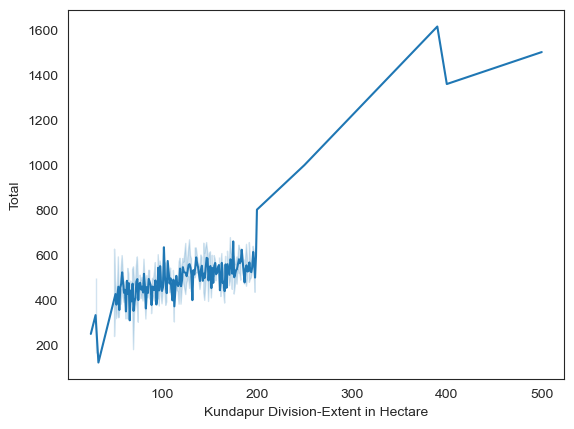

In [38]:
sns.lineplot(x="Kundapur Division-Extent in Hectare", y="Total", data=df)
sns.set_style('darkgrid')
plt.show()

# Visualization: Total Trend of Land Extent Over the Years in Kundapur Division-Extent in Hectare

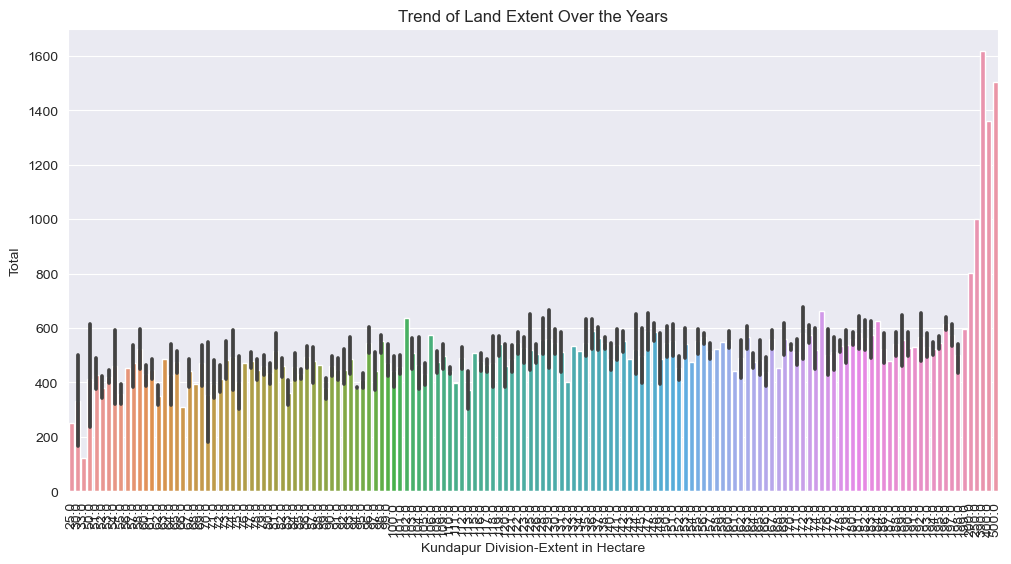

In [40]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df.reset_index(), x='Kundapur Division-Extent in Hectare', y='Total')
plt.title('Trend of Land Extent Over the Years')
plt.xlabel('Kundapur Division-Extent in Hectare')
plt.ylabel('Total')
plt.xticks(rotation=90)
plt.show()

# pair plot for Total Trend of Land Extent Over the Years in Kundapur Division-Extent in Hectare

<Figure size 1200x600 with 0 Axes>

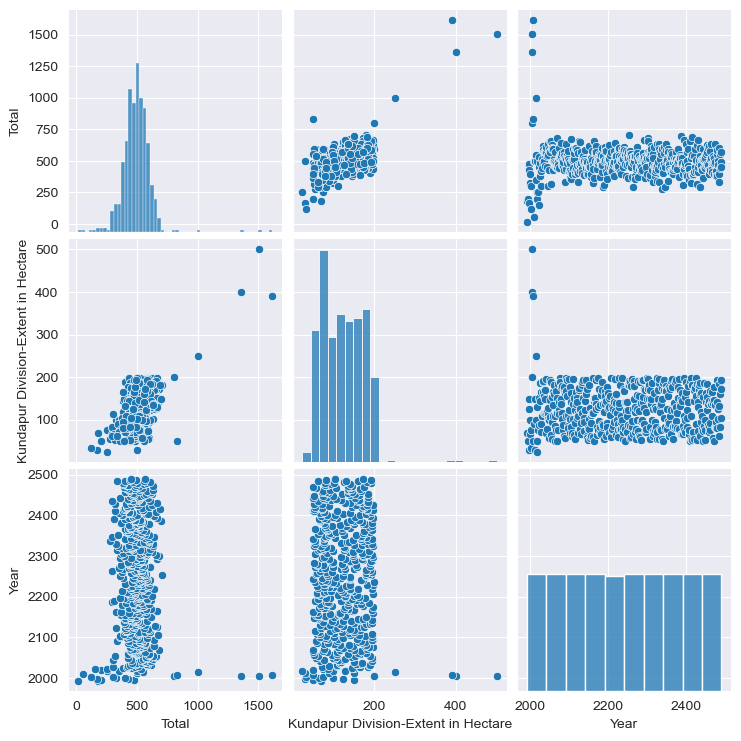

In [41]:
plt.figure(figsize=(12, 6))
sns.pairplot(df, vars=['Total', 'Kundapur Division-Extent in Hectare', 'Year'])
plt.show()

# hist plot of Puttur Division-Extent in Hectare with brown color

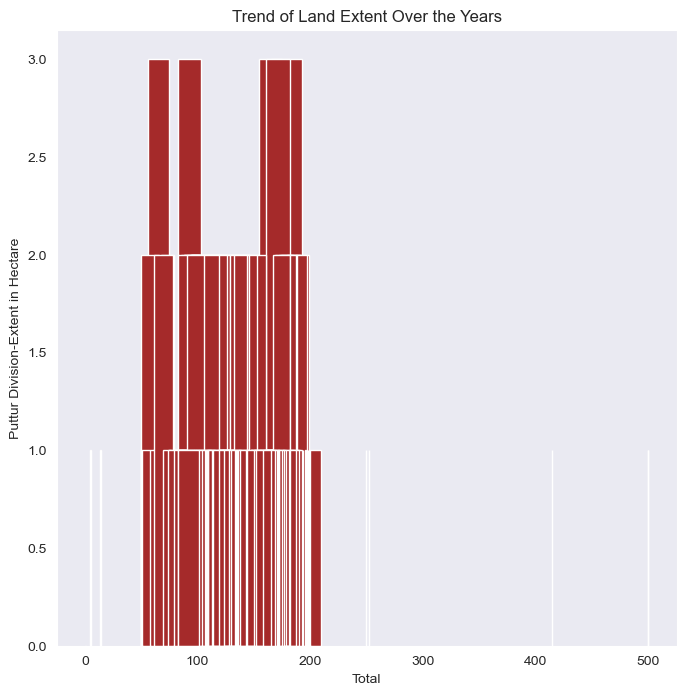

In [42]:
import matplotlib.pyplot as plt
df1=df.groupby('Total')['Puttur Division-Extent in Hectare']
df1.hist(color = 'brown',figsize=[8,8],grid=False,bins=5)
plt.title("Trend of Land Extent Over the Years")
plt.xlabel("Total")
plt.ylabel("Puttur Division-Extent in Hectare")
plt.show()

# sactter plot of Puttur Division-Extent in Hectare with orange color

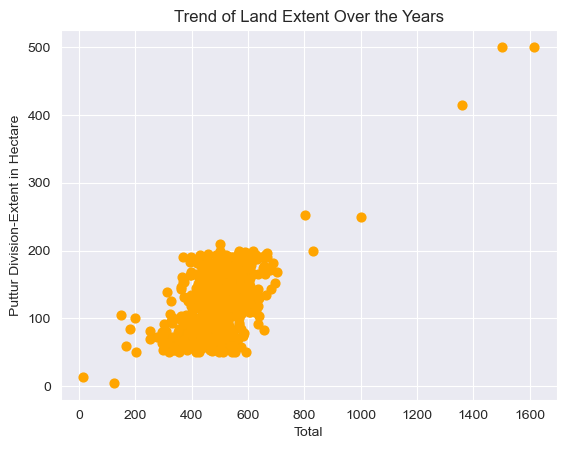

In [43]:
df.plot.scatter(x='Total',y='Puttur Division-Extent in Hectare',color='orange',s=40)
plt.title("Trend of Land Extent Over the Years")
plt.show()

# box plot of Puttur Division-Extent in Hectare with blue color

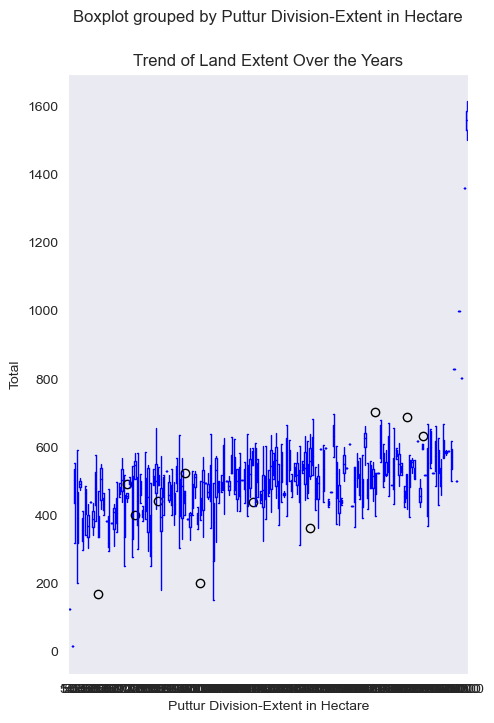

In [44]:
df.boxplot(by='Puttur Division-Extent in Hectare', column =['Total'], grid = False,color='blue',figsize=[5,8])
plt.title("Trend of Land Extent Over the Years")
plt.ylabel("Total")
plt.show()

# plot line  of Puttur Division-Extent in Hectare with orange color

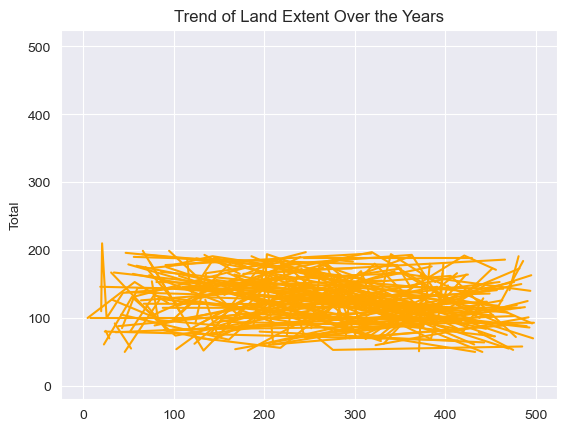

In [45]:
df1.plot.line(x='Puttur Division-Extent in Hectare',y='Total',color='orange')
plt.title("Trend of Land Extent Over the Years")
plt.ylabel("Total")
plt.show()

# pie plot  of Puttur Division-Extent in Hectare

Text(0.5, 1.0, 'Trend of Land Extent Over the Years')

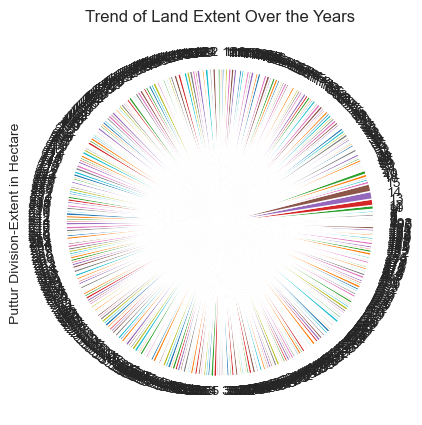

In [46]:
df['Puttur Division-Extent in Hectare'].plot(kind='pie',subplots=True,figsize=(5,5))
plt.title("Trend of Land Extent Over the Years")

# Puttur Division-Extent in Hectare in seaborn with lineplot

<AxesSubplot:title={'center':'Trend of Land Extent Over the Years'}, xlabel='Puttur Division-Extent in Hectare', ylabel='Total'>

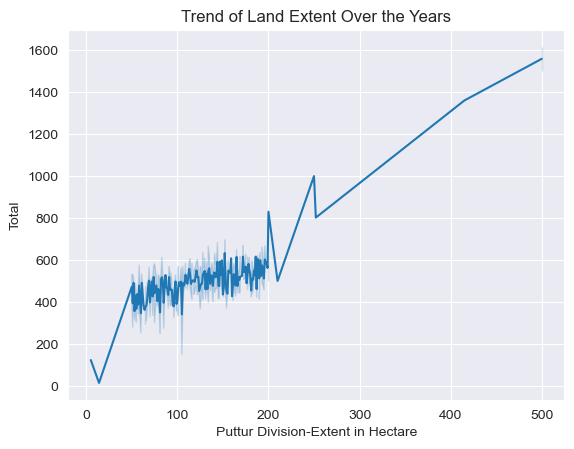

In [47]:
plt.title('Trend of Land Extent Over the Years')
sns.lineplot(x="Puttur Division-Extent in Hectare", y="Total", data=df) 

# line plot of Puttur Division-Extent in Hectare in seaborn with darkgrid

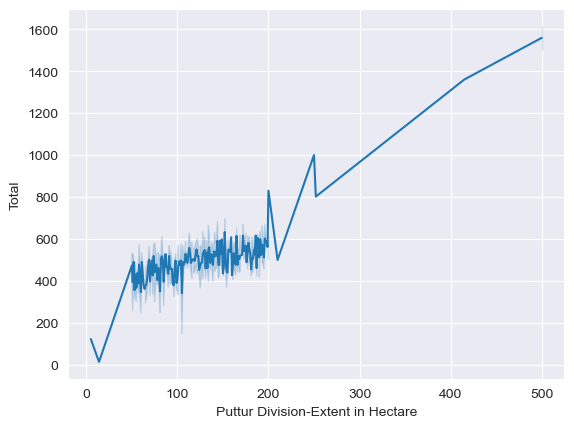

In [48]:
sns.lineplot(x="Puttur Division-Extent in Hectare", y="Total", data=df)
sns.set_style('darkgrid')
plt.show()

# Visualization: Total Trend of Land Extent Over the Years in Puttur Division-Extent in Hectare 

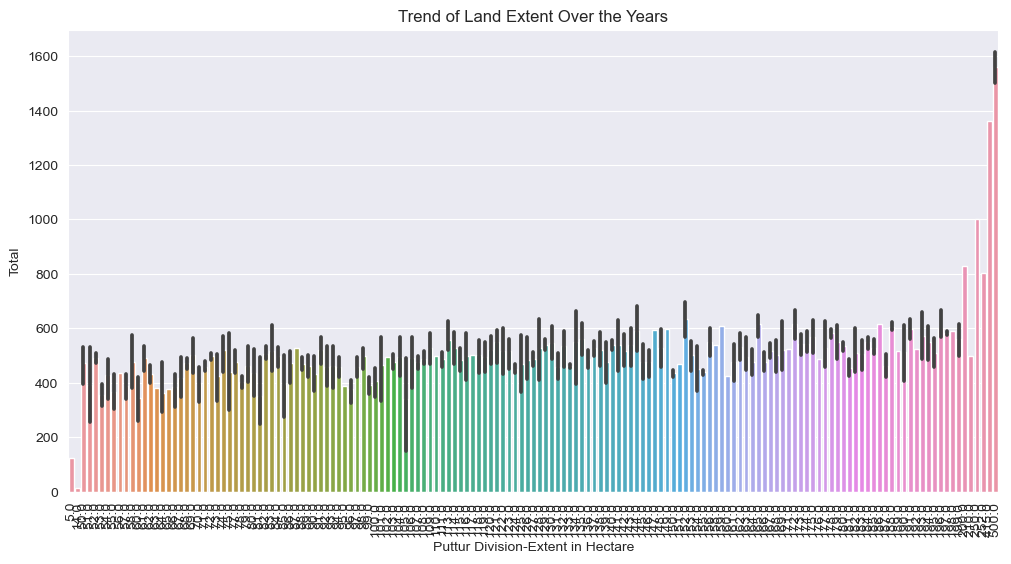

In [49]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df.reset_index(), x='Puttur Division-Extent in Hectare', y='Total')
plt.title('Trend of Land Extent Over the Years')
plt.xlabel('Puttur Division-Extent in Hectare')
plt.ylabel('Total')
plt.xticks(rotation=90)
plt.show()

# pair plot for Total Trend of Land Extent Over the Years in Puttur Division-Extent in Hectare

<Figure size 1200x600 with 0 Axes>

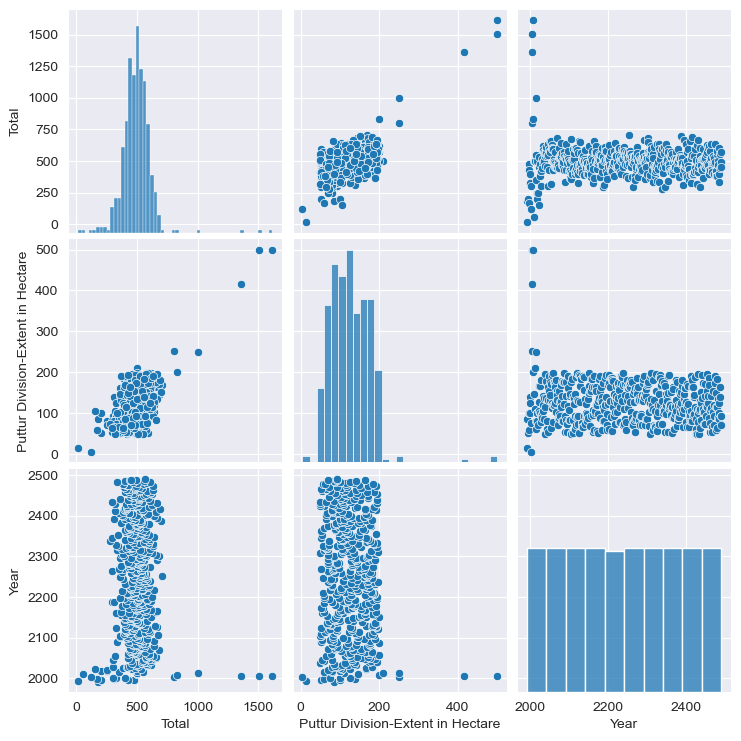

In [50]:
plt.figure(figsize=(12, 6))
sns.pairplot(df, vars=['Total', 'Puttur Division-Extent in Hectare', 'Year'])
plt.show()

# hist plot of Moodabidri Division-Extent in Hectare with brown color

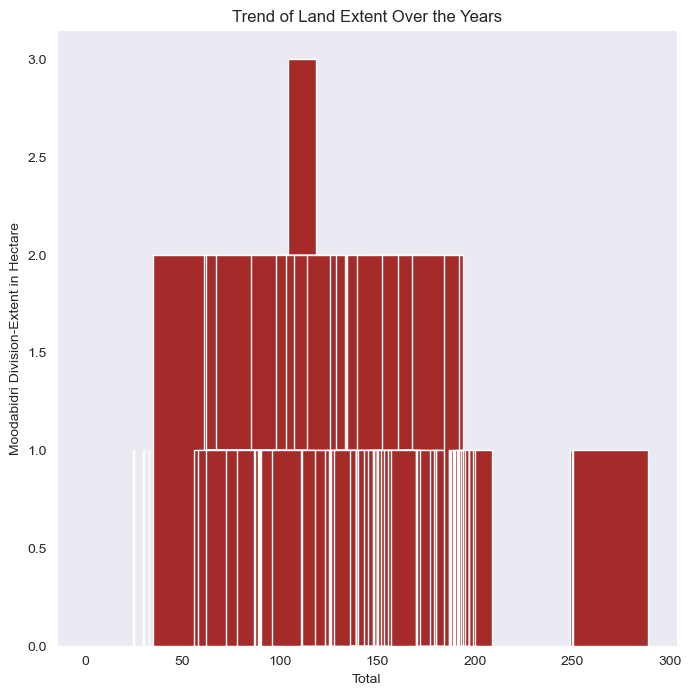

In [51]:
import matplotlib.pyplot as plt
df1=df.groupby('Total')['Moodabidri Division-Extent in Hectare']
df1.hist(color = 'brown',figsize=[8,8],grid=False,bins=5)
plt.title("Trend of Land Extent Over the Years")
plt.xlabel("Total")
plt.ylabel("Moodabidri Division-Extent in Hectare")
plt.show()

# sactter plot of Moodabidri Division-Extent in Hectare with orange color

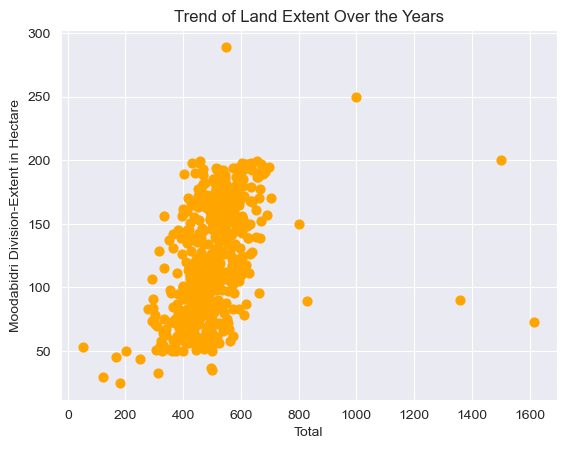

In [52]:
df.plot.scatter(x='Total',y='Moodabidri Division-Extent in Hectare',color='orange',s=40)
plt.title("Trend of Land Extent Over the Years")
plt.show()

# box plot of Moodabidri Division-Extent in Hectaree with blue color

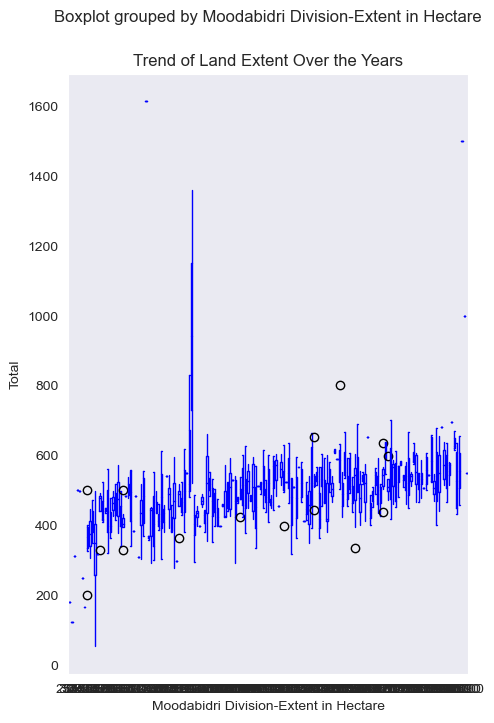

In [53]:
df.boxplot(by='Moodabidri Division-Extent in Hectare', column =['Total'], grid = False,color='blue',figsize=[5,8])
plt.title("Trend of Land Extent Over the Years")
plt.ylabel("Total")
plt.show()

# plot line  of Moodabidri Division-Extent in Hectare with orange color

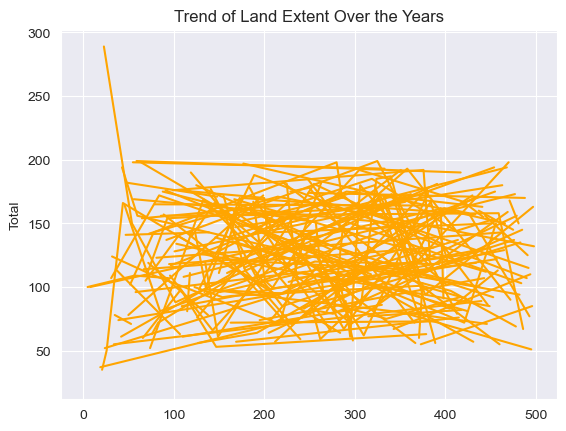

In [54]:
df1.plot.line(x='Moodabidri Division-Extent in Hectare',y='Total',color='orange')
plt.title("Trend of Land Extent Over the Years")
plt.ylabel("Total")
plt.show()

# pie plot  of Moodabidri Division-Extent in Hectare

Text(0.5, 1.0, 'Trend of Land Extent Over the Years')

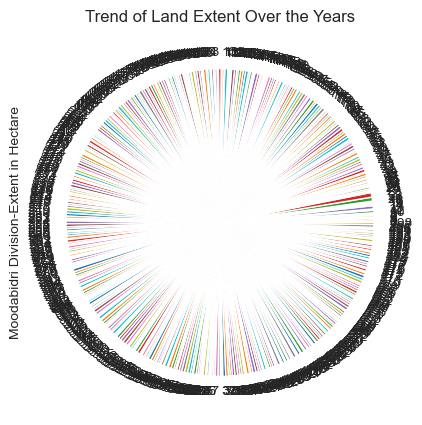

In [55]:
df['Moodabidri Division-Extent in Hectare'].plot(kind='pie',subplots=True,figsize=(5,5))
plt.title("Trend of Land Extent Over the Years")

# line plot of Moodabidri Division-Extent in Hectare in seaborn with darkgrid

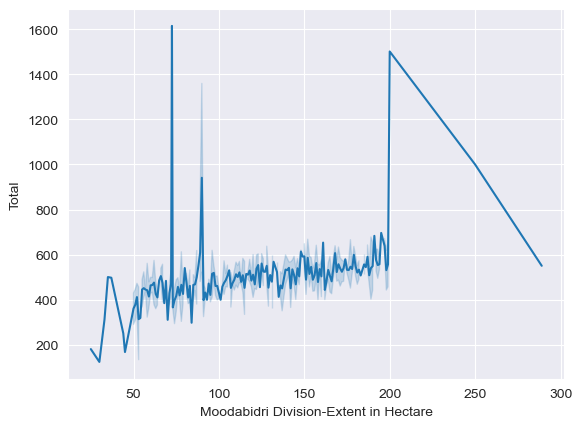

In [56]:
sns.lineplot(x="Moodabidri Division-Extent in Hectare", y="Total", data=df)
sns.set_style('darkgrid')
plt.show()

# line plot  Puttur Division-Extent in Hectare in seaborn with despine

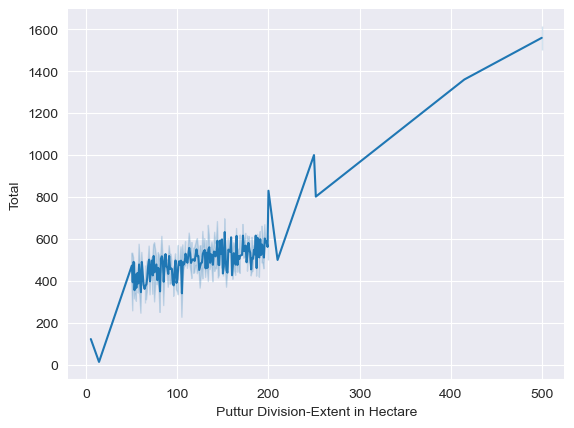

In [57]:
sns.lineplot(x="Puttur Division-Extent in Hectare", y="Total", data=df)
sns.despine(left=True)
plt.show()

# Visualization: Total Trend of Land Extent Over the Years in Moodabidri Division-Extent in Hectare 

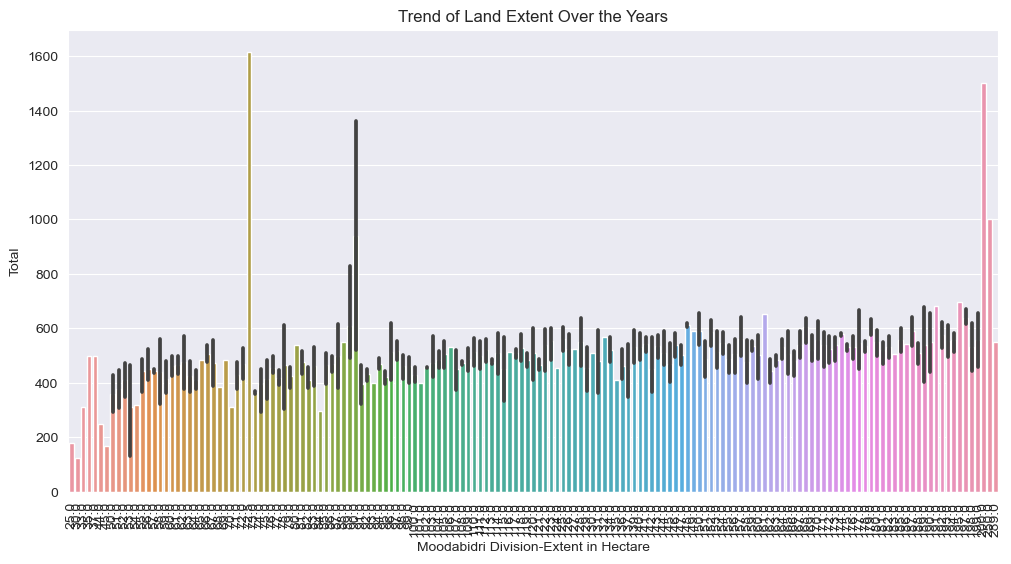

In [58]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df.reset_index(), x='Moodabidri Division-Extent in Hectare', y='Total')
plt.title('Trend of Land Extent Over the Years')
plt.xlabel('Moodabidri Division-Extent in Hectare')
plt.ylabel('Total')
plt.xticks(rotation=90)
plt.show()

# pair plot for Total Trend of Land Extent Over the Years in Puttur Division-Extent in Hectare

<Figure size 1200x600 with 0 Axes>

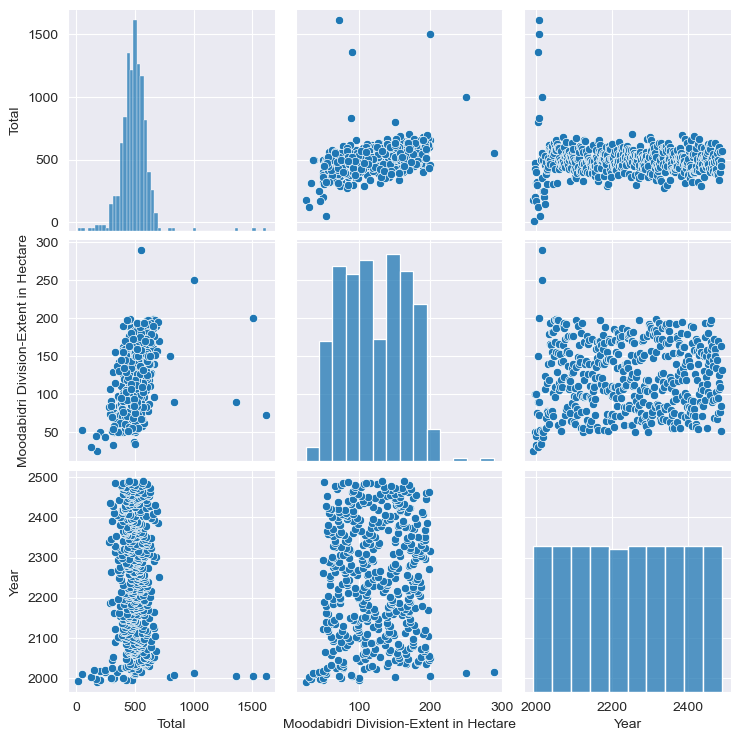

In [59]:
plt.figure(figsize=(12, 6))
sns.pairplot(df, vars=['Total', 'Moodabidri Division-Extent in Hectare', 'Year'])
plt.show()

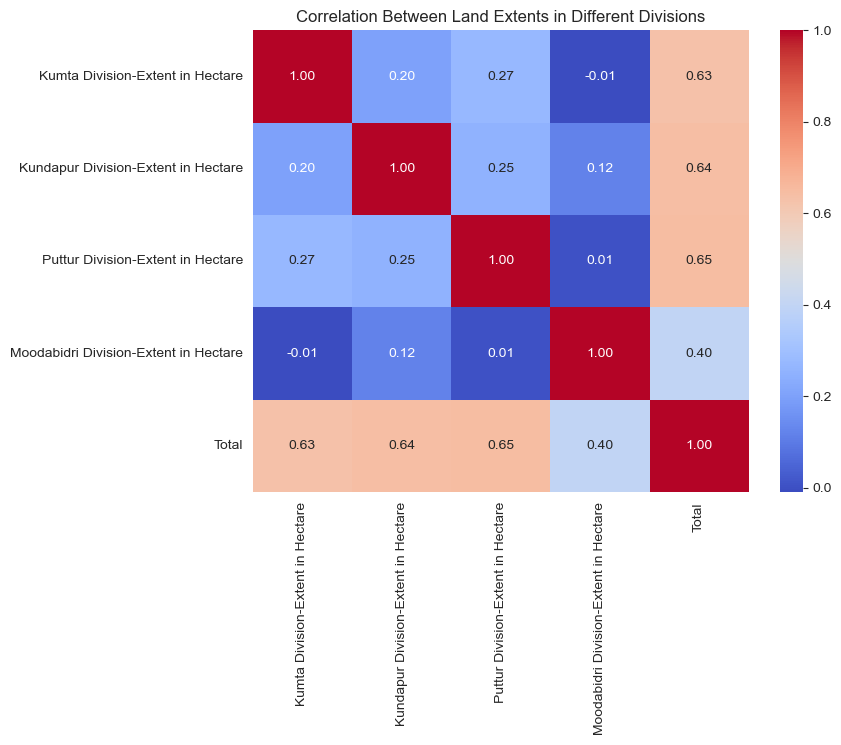

In [60]:
correlation_matrix = df_filled.iloc[:, 2:].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Land Extents in Different Divisions")
plt.show()


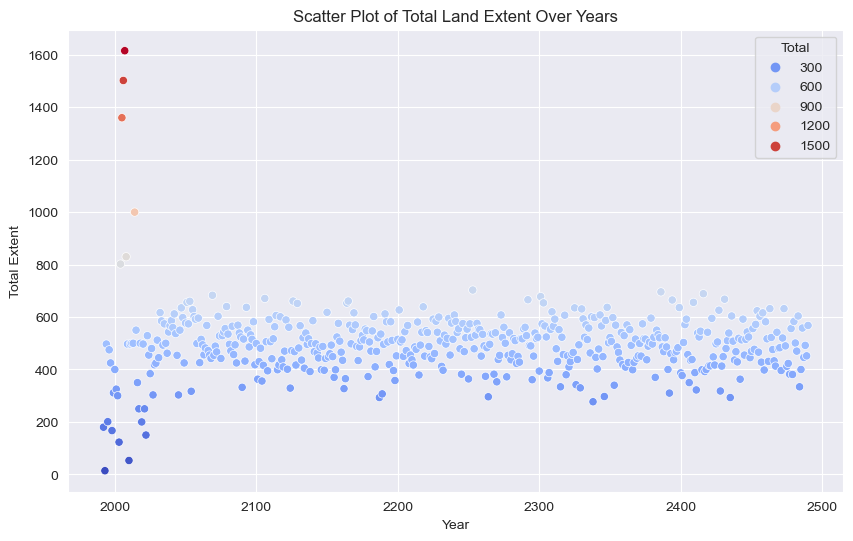

In [61]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_filled["Year"], y=df_filled["Total"], hue=df_filled["Total"], palette="coolwarm")
plt.title("Scatter Plot of Total Land Extent Over Years")
plt.xlabel("Year")
plt.ylabel("Total Extent")
plt.show()

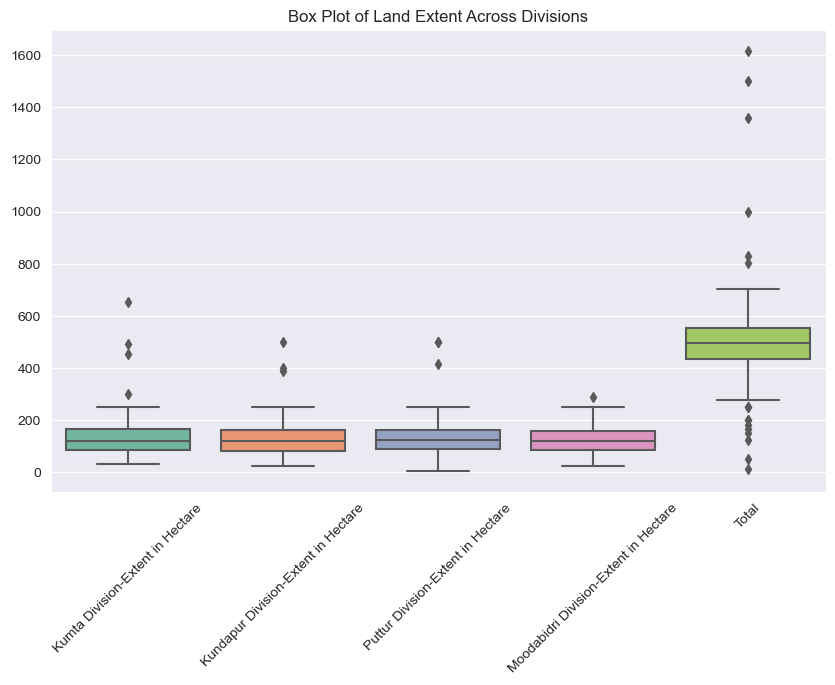

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filled.iloc[:, 2:], palette="Set2")
plt.title("Box Plot of Land Extent Across Divisions")
plt.xticks(rotation=45)
plt.show()


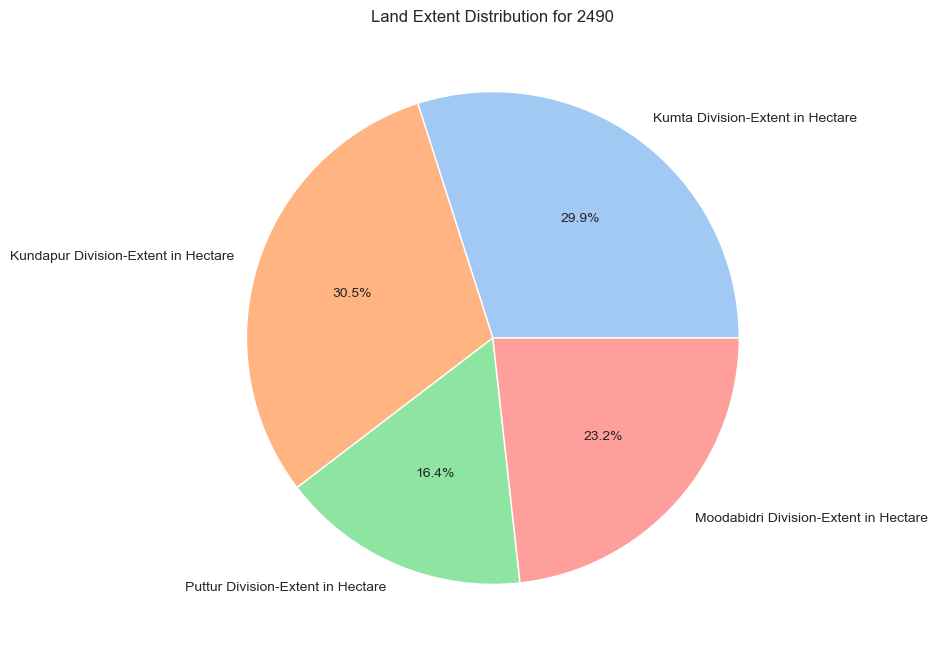

In [63]:
latest_year = df_filled["Year"].max()
latest_data = df_filled[df_filled["Year"] == latest_year].iloc[:, 2:-1].sum()
plt.figure(figsize=(8, 8))
plt.pie(latest_data, labels=latest_data.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title(f"Land Extent Distribution for {latest_year}")
plt.show()


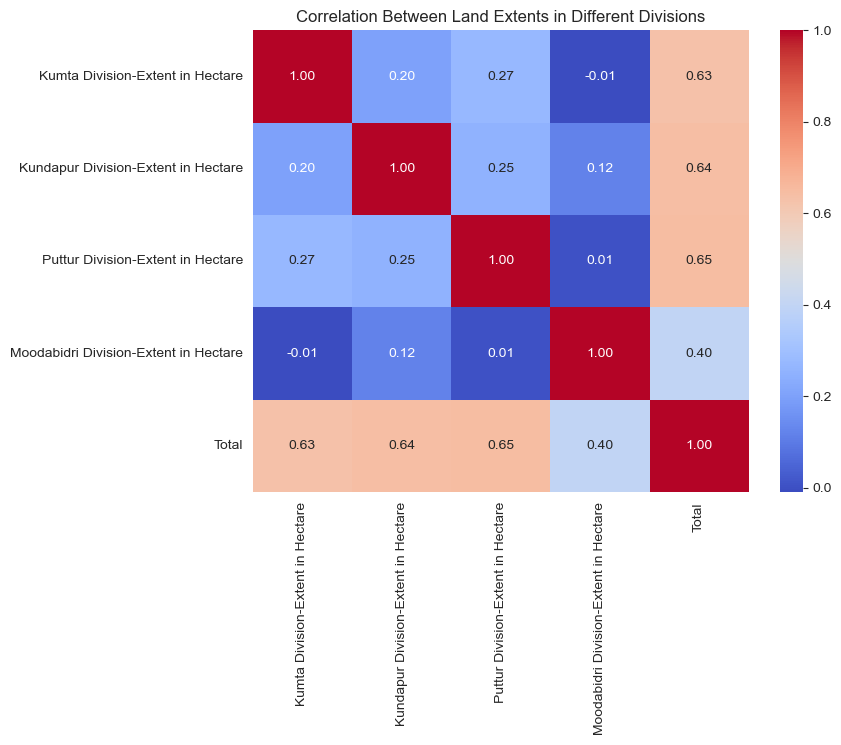

In [67]:
correlation_matrix = df_filled.iloc[:, 2:].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Land Extents in Different Divisions")
plt.show()


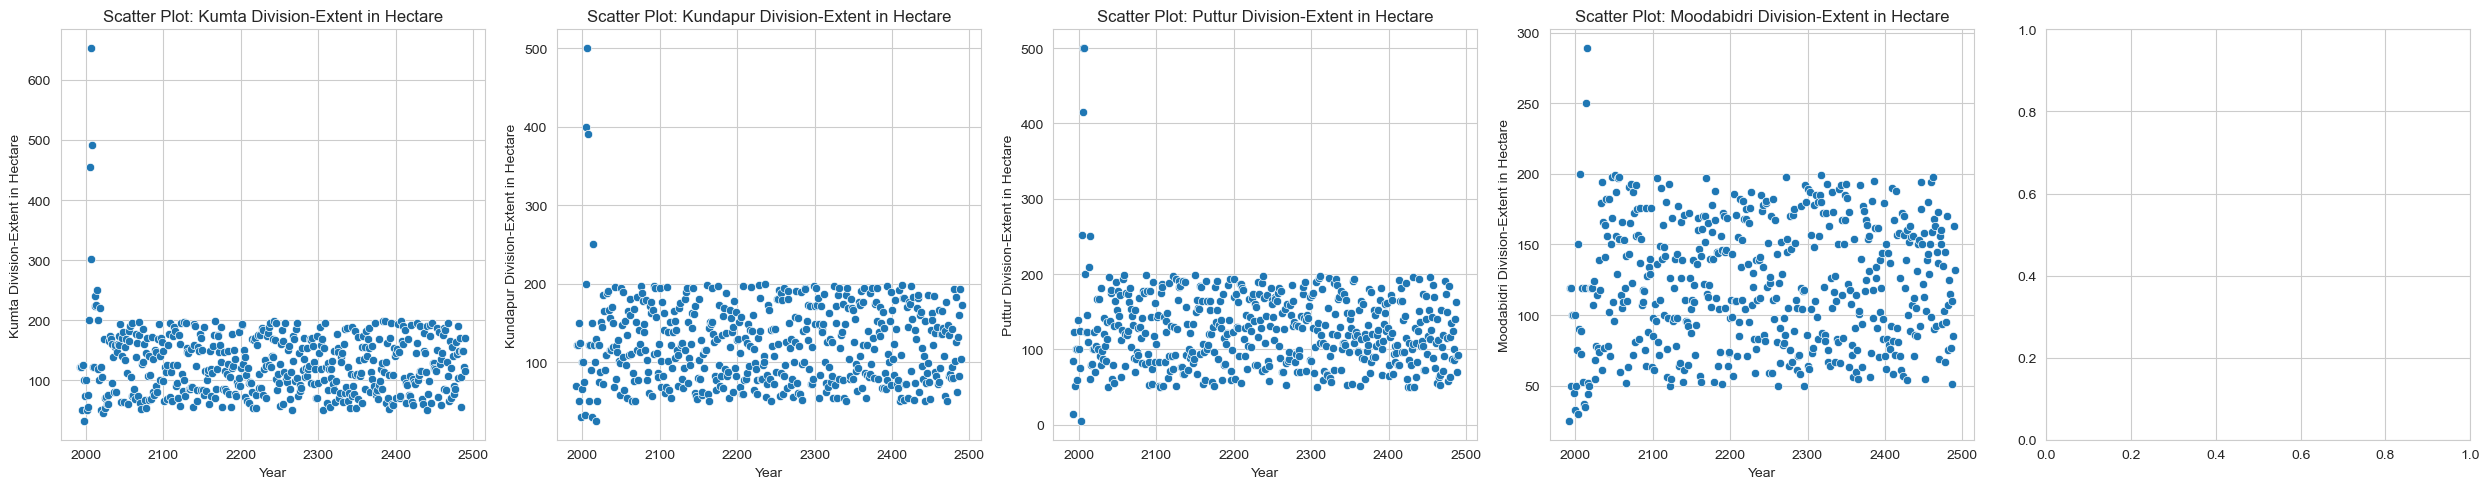

In [68]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
columns = df.columns[2:-1]
for col, ax in zip(columns, axes):
    sns.scatterplot(x=df_filled["Year"], y=df_filled[col], ax=ax)
    ax.set_title(f"Scatter Plot: {col}")
plt.tight_layout()
plt.show()

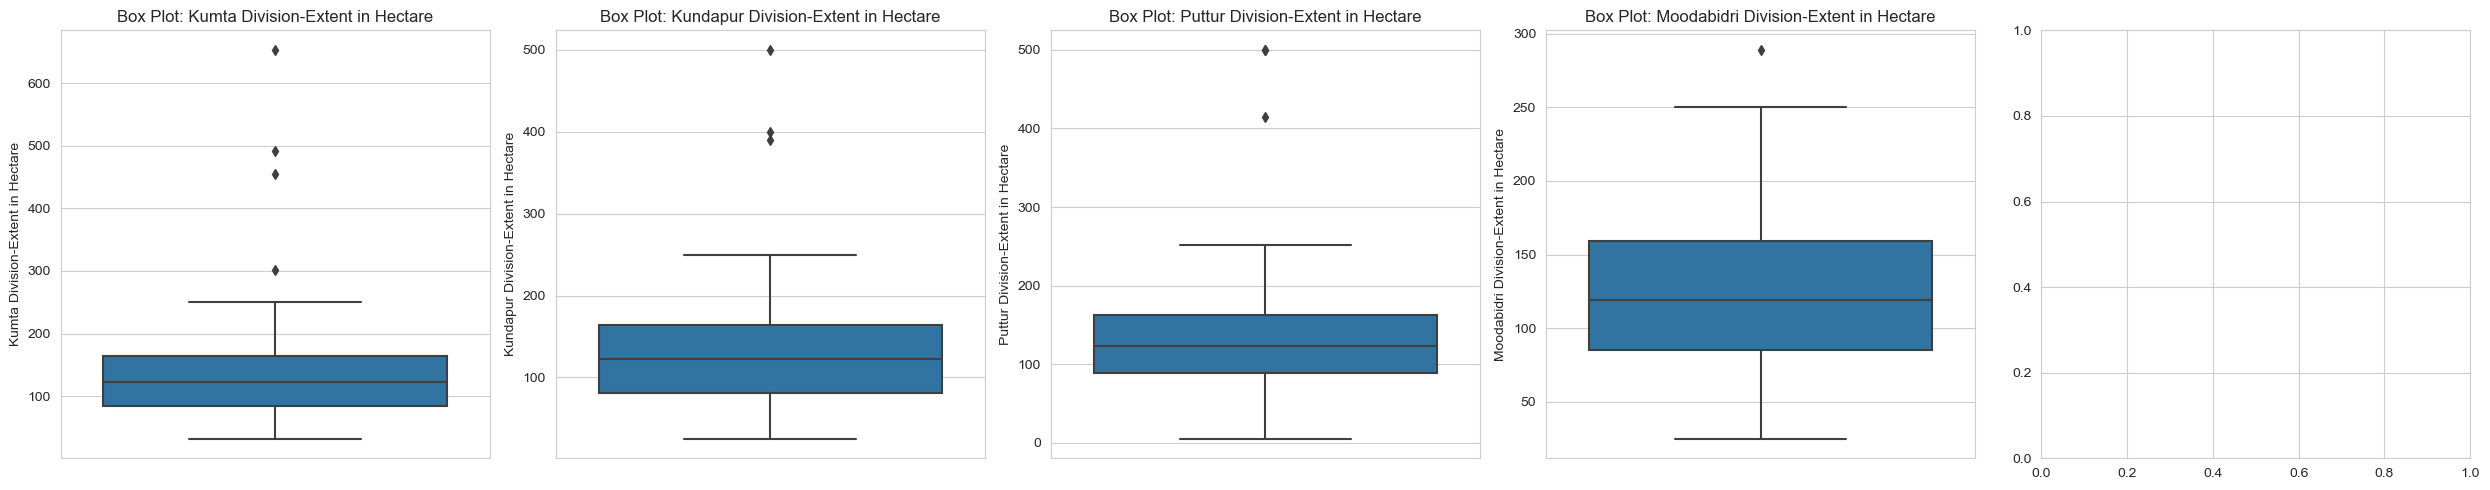

In [69]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for col, ax in zip(columns, axes):
    sns.boxplot(y=df_filled[col], ax=ax)
    ax.set_title(f"Box Plot: {col}")
plt.tight_layout()
plt.show()


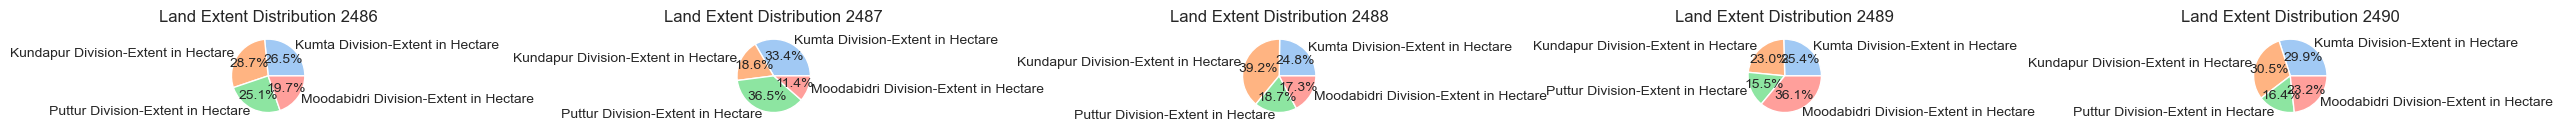

In [70]:
years = df_filled["Year"].unique()[-5:]
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for year, ax in zip(years, axes):
    year_data = df_filled[df_filled["Year"] == year].iloc[:, 2:-1].sum()
    ax.pie(year_data, labels=year_data.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"))
    ax.set_title(f"Land Extent Distribution {year}")
plt.tight_layout()
plt.show()